<a href="https://colab.research.google.com/github/krishhh-na/Tareas-FIS1344-1/blob/main/Tarea_2_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Primer código:

In [ ]:
n = 1000
s = 0
for i in range(n):
    for j in range(n):
        if i < j:
            s = s + i + j

vemos que el primer 'for' se repite n veces, lo mismo pasa con el segundo 'for', por lo tanto:  n * n = $n^2$ = O($n^2$) y c = 2.



Segundo código:

In [ ]:
n = 1000
s = 0
for i in range(n):
    for j in range(i):
        s = s + i + j

vemos que el primero 'for' corre en n, pero el segundo 'for' depende de i.

 por otro lado, si suponemos que n = 6  y reemplazamos en s = s + i + j, el segundo ciclo nos quedaria 0+1+2+3+4+5= 15, entonces para cualquier n seria 0+1+2+..+(n-1)= $\frac{n(n-1)}{2}$ = $\frac{n^2 - n}{2}$, para valores grandes de n el término que nos importa es $\frac{n^2}{2}$, ignoramos la constante 1/2, nos queda O($n^2$) y c = 2.

la función sum() suma todos los elementos, sum(range(n)) calcula la suma de todos los números enteros desde el 0 hasta (n-1)

Tercer código:

In [ ]:
n = 1000
s = 0
for i in range(n):
    s = s + i + sum(range(n))

vemos que 'for' se repite n veces, igualmente que sum(range(n)),entonces tenemos que n * n = $n^2$ = O($n^2$) y c = 2.


Cuarto código:

In [ ]:
n = 100000
small = 0
p = 146
attempt = n//2
not_found = True
s = 0
while not_found:
    s = s + 1
    if attempt > p:
        n = attempt
    elif attempt < p:
        small = attempt
    else:
        print('Encontré', attempt, 'luego de', s, 'pasos')
        break
    attempt = (n + small)//2

vemos que al inicio tenemos el intervalo [0,100000] pero queremos encontrar p = 146.

El primer intento es 100000/2 = 50000 pero no se encuentra;

 con 'while not_found' decimos que mientras no encuentre el número sigue buscando y en cada vuelta aumentara el contador con s = s + 1, después con 'if attempt > p:
        n = attempt' dice que si usamos un número mayor a 146 no vale la pena seguir buscando por encima de el, probando con n = 50000 ahora el intervalo es [0,50000] y asi sucesivamente.

usando 'elif attempt < p:
        small = attempt' le indicamos que si attempt= 100 y 100<146, la respuesta no puede estar entre 0 y 100, entonces con small=100 ajustamos que el limite inferior de la busqueda sera 100.

En conclusión, podemos ver que la busqueda trata de ir reduciendo los números(posibilidades) a la mitad para ir acercandose al objetivo, o sea: $\frac{n}{2}$, después $\frac{n}{4}$, después $\frac{n}{8}$, ...

entonces, después de s pasos: $\frac{n}{2^s}$, cuando ya queda aprox un solo número $\frac{n}{2^s}$ = 1 y n = ${2^s}$, tomamos logaritmo base dos: s = $\log_2(n)$.

así, O($\log_2(n)$).


Como nos indican, aumentaremos n y veremos como cambia el número de pasos, garficandolo después:

[1000, 2000, 5000, 10000, 20000, 50000, 100000]
[9, 10, 9, 10, 11, 10, 11]


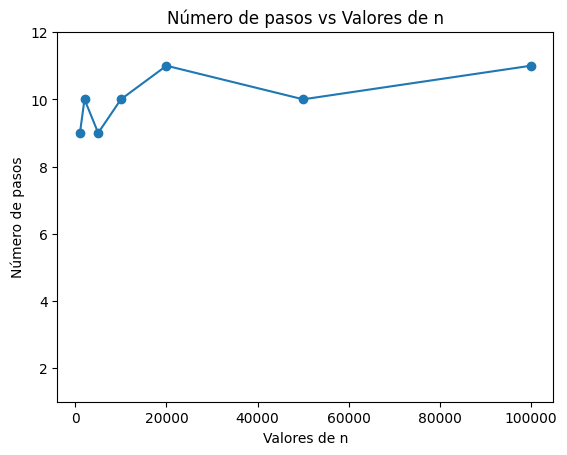

In [5]:
import matplotlib.pyplot as plt
valores_n = [1000,2000,5000,10000,20000,50000,100000]     #probamos valores de n
pasos = []
for n_inicial in valores_n:
  n = n_inicial
  small = 0
  p = 146
  attempt = n//2
  no_encontrado = True
  s = 0

  while no_encontrado:
      s = s + 1
      if attempt > p:                    #si el valor es mayor a p, descarta la mitad superior del intervalo
        n = attempt

      elif attempt < p:
        small = attempt                  # si es menor a p, descarta la mitad inferior del intervalo

      else:                              # si es igual a p, se termina la busqueda
        break

      attempt = (n + small)//2           # calculara un nuevo intento entre el limite inferior y limite superior
  pasos.append(s)

print(valores_n)
print(pasos)
plt.plot(valores_n, pasos, 'o-')
plt.xlabel('Valores de n')
plt.ylabel('Número de pasos')
plt.title('Número de pasos vs Valores de n')
plt.ylim(1,12)
plt.show()

Observando el comportamiento del gráfico, vemos que los pasos aumentan muy poco a medida que aumenta el valor de n, como vimos anteriormente, esto corresponde a un crecimiento logaritmico: O($\log_2(n)$).